# Regression
Course: https://www.kaggle.com/learn/time-series

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
data_dir = Path("./data/")

ed18_data = pd.read_csv(
    data_dir / "ED18_03112023.csv",
    index_col="datetime",
    parse_dates=["datetime"],
).drop(
    [
        "_id",
        "unit_id",
        "rounded_datatime",
    ],
    axis=1,
)

# equivalent but more verbose: df = ed18_data.loc[:, "TotVA"].to_frame() 
df = ed18_data[["TotVA"]]

In [3]:
print(f'Dropping NaN {df.loc[:, "TotVA"].isna().sum()} values.')
df = df.dropna()

Dropping NaN 174 values.


In [4]:
from sklearn.linear_model import LinearRegression

# create a time-step feature
df["time"] = np.arange(len(df.index))

model = LinearRegression()

# create training data
X = df.loc[:, ["time"]]
y = df.loc[:, "TotVA"]

model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

## Computing the regression line

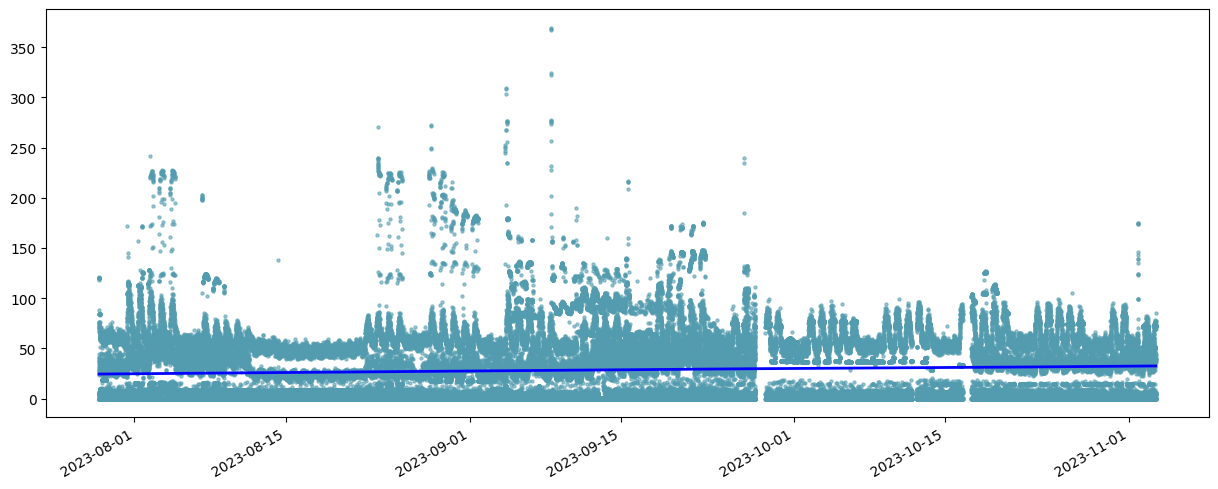

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(
    df.index,
    df["TotVA"],
    s=5,
    color="#539caf",
    alpha=0.55,
)

ax.plot(y_pred, color="blue", linewidth=2)

# formatting the xlabels
plt.gcf().autofmt_xdate()

## Lag plots

In [6]:
df_lag = pd.DataFrame({
    "y": df["TotVA"],
    "y_lag_1": df["TotVA"].shift(1),
    "y_lag_2": df["TotVA"].shift(2),
})

df_lag = df_lag.to_period("M")

df_lag = df_lag.dropna()

df_lag.head(10)

,y,y_lag_1,y_lag_2
datetime,,,
2023-07,84.51745,37.55411,4.62000
2023-07,0.00000,84.51745,37.55411
2023-07,88.03688,0.00000,84.51745
2023-07,4.26000,88.03688,0.00000
2023-07,27.68911,4.26000,88.03688
2023-07,83.99799,27.68911,4.26000
2023-07,0.00000,83.99799,27.68911
2023-07,76.37672,0.00000,83.99799
2023-07,3.36000,76.37672,0.00000


In [7]:
# compute regression lines for lag plots
X = df_lag.loc[:, ["y"]]
y_lag_preds = []
for y in [df_lag.loc[:, "y_lag_1"], df_lag.loc[:, "y_lag_2"]]:
    model = LinearRegression()
    model.fit(X, y)
    y_lag_preds.append(model.predict(X))

In [8]:
df_lag

,y,y_lag_1,y_lag_2
datetime,,,
2023-07,84.51745,37.55411,4.62000
2023-07,0.00000,84.51745,37.55411
2023-07,88.03688,0.00000,84.51745
2023-07,4.26000,88.03688,0.00000
2023-07,27.68911,4.26000,88.03688
...,...,...,...
2023-11,0.00000,71.08148,6.99000
2023-11,44.86346,0.00000,71.08148
2023-11,72.46983,44.86346,0.00000


In [9]:
y_lag_preds

[array([23.24993563, 31.07522903, 22.92407899, ..., 24.36539949,
        30.55303326, 24.62544743]),
 array([20.68789498, 32.37471419, 20.20123877, ..., 22.3538037 ,
        31.59483192, 22.74217677])]

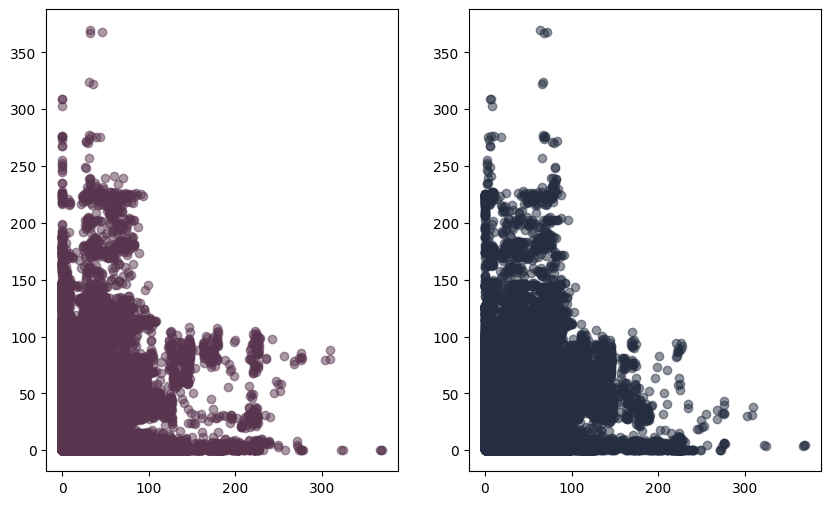

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 6))

ax1.scatter(x=df_lag["y"], y=df_lag["y_lag_1"], color="#58344F", alpha=0.5)
ax2.scatter(x=df_lag["y"], y=df_lag["y_lag_2"], color="#252E41", alpha=0.5)

# ax1.plot(y_lag_preds[0], color="black")
# ax2.plot(y_lag_preds[1], color="black")